In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import date
from scipy.stats import norm
from scipy.optimize import brentq, newton
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Black-Scholes
def bs_price(S, K, r, T, sigma, option="call"):
    if sigma <= 0 or T <= 0:
        # Límite: precio intrínseco descontado
        if option == "call":
            return max(0.0, S - K*np.exp(-r*T))
        else:
            return max(0.0, K*np.exp(-r*T) - S)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option.lower() == "call":
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def bs_vega(S, K, r, T, sigma):
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)  # en unidades de precio por 1.0 de sigma


def implied_vol(price_mkt, S, K, r, T, option="call", brent_bounds=(1e-6, 5.0), tol=1e-8, maxiter=100):

    # Verificación de límites teóricos: el precio debe estar entre [intrínseco, cota superior]
    if option == "call":
        lower = max(0.0, S - K*np.exp(-r*T))
        upper = S
    else:
        lower = max(0.0, K*np.exp(-r*T) - S)
        upper = K*np.exp(-r*T)

    if not (lower - 1e-12 <= price_mkt <= upper + 1e-12):
        raise ValueError(f"Precio de mercado fuera de rango teórico [{lower:.4f}, {upper:.4f}]")

    # Función objetivo
    def f(sig):
        return bs_price(S, K, r, T, sig, option) - price_mkt

    a, b = brent_bounds
    fa, fb = f(a), f(b)

    # Ajusta el extremo superior si no cambia de signo (intenta ampliar)
    if fa*fb > 0:
        # intenta expandir b
        for b_try in [10.0, 15.0, 25.0, 50.0]:
            fb = f(b_try)
            if fa*fb <= 0:
                b = b_try
                break

    # Intenta Brent
    try:
        iv = brentq(f, a, b, xtol=tol, maxiter=maxiter)
        return iv
    except Exception:
        pass

    # Si Brent falla, intenta método de Newton
    seed = min(max(sigma_hist if 'sigma_hist' in globals() and np.isfinite(sigma_hist) else 0.2, 1e-3), 2.0)
    try:
        iv = newton(lambda s: f(s), seed, fprime=lambda s: bs_vega(S, K, r, T, s), tol=tol, maxiter=maxiter)
        if iv > 0:
            return iv
    except Exception:
        pass

    raise RuntimeError("No se pudo encontrar una volatilidad implícita con los métodos intentados.")




In [6]:
ticker = 'SPY'

tk    = yf.Ticker(ticker)
exp = '2026-04-17'
today  = date.today()

data = yf.download(ticker, start='2022-01-01', end=today, progress=False)['Close']
S0 = float(data.iloc[-1])
r     = 0.042
K     = 680
T     = (date.fromisoformat(exp) - date.today()).days / 365

# solo informativo
daily_returns = data.pct_change().dropna()
sigma_hist = float(daily_returns.std() * np.sqrt(252))


# Precio mid: promedio de bid y ask, más estable que el último trade
chain    = tk.option_chain(exp).calls
row      = chain[chain['strike'] == K].iloc[0]
C_market = (row['bid'] + row['ask']) / 2

print(f"S0={S0:.2f} | bid={row['bid']:.2f} ask={row['ask']:.2f} mid={C_market:.4f}")
iv = implied_vol(C_market, S0, K, r, T, option="call")

bs_check = bs_price(S0, K, r, T, iv, option="call")
error    = abs(bs_check - C_market)

print(f"IV :        {iv:.4%}")
print(f"BS, C (IV): {bs_check:.6f}")
print(f"C_market     :{C_market:.6f}")

S0=648.57 | bid=3.68 ask=3.73 mid=3.7050
IV :        19.3422%
BS, C (IV): 3.705000
C_market     :3.705000


Puntos válidos: 652


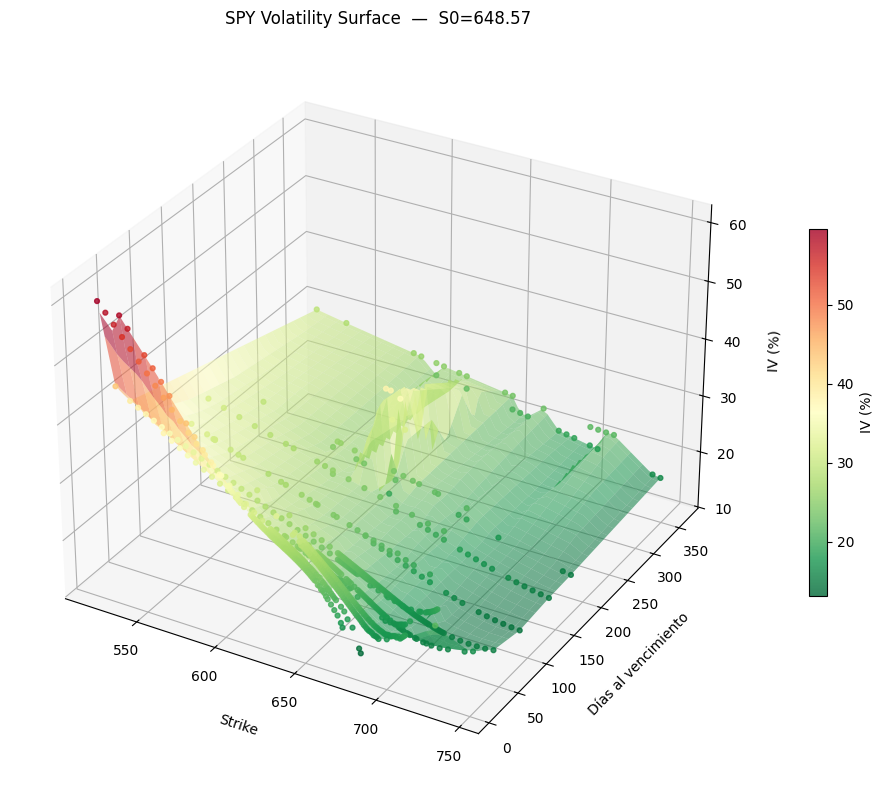

In [7]:
all_exps = [(e, (date.fromisoformat(e) - today).days)
            for e in tk.options
            if 7 <= (date.fromisoformat(e) - today).days <= 400]

# 8 vencimientos espaciados uniformemente entre 7 y 400 días
idx  = np.linspace(0, len(all_exps) - 1, min(8, len(all_exps)), dtype=int)
exps = [all_exps[i][0] for i in idx]

records = []

for exp in exps:
    T = (date.fromisoformat(exp) - today).days / 365

    # Calls y puts
    calls = tk.option_chain(exp).calls.copy()
    puts  = tk.option_chain(exp).puts.copy()

    for df, opt_type in [(calls, "call"), (puts, "put")]:
        # Filtros de liquidez y spread
        df = df[
            (df['bid'] > 0) &
            (df['ask'] > 0) &
            (df['volume'].fillna(0) > 50) &
            (df['ask'] / df['bid'] < 3.0) &
            (df['strike'] >= S0 * 0.80) &
            (df['strike'] <= S0 * 1.15)
        ].copy()
        df['mid'] = (df['bid'] + df['ask']) / 2

        for _, row in df.iterrows():
            K   = row['strike']
            mid = row['mid']
            try:
                iv = implied_vol(mid, S0, K, r, T, option=opt_type)
                if 0.05 <= iv <= 2.0:   # descarta IVs absurdas
                    records.append({
                        'expiry'  : exp,
                        'days'    : round(T * 365),
                        'K'       : K,
                        'moneyness': K / S0,
                        'type'    : opt_type,
                        'IV'      : iv * 100
                    })
            except Exception:
                pass

df_surf = pd.DataFrame(records)
print(f"Puntos válidos: {len(df_surf)}")

# Plot 3D
fig = plt.figure(figsize=(13, 8))
ax  = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_surf['K'],
    df_surf['days'],
    df_surf['IV'],
    c=df_surf['IV'],
    cmap='RdYlGn_r',
    s=12,
    alpha=0.8
)

# Superficie interpolada encima de los puntos
from scipy.interpolate import griddata

ki   = np.linspace(df_surf['K'].min(),    df_surf['K'].max(),    60)
ti   = np.linspace(df_surf['days'].min(), df_surf['days'].max(), 60)
KK, TT = np.meshgrid(ki, ti)
IV_grid = griddata(
    (df_surf['K'], df_surf['days']),
    df_surf['IV'],
    (KK, TT),
    method='linear'
)

ax.plot_surface(KK, TT, IV_grid, cmap='RdYlGn_r', alpha=0.55, linewidth=0)

ax.set_xlabel('Strike',              labelpad=10)
ax.set_ylabel('Días al vencimiento', labelpad=10)
ax.set_zlabel('IV (%)',              labelpad=10)
ax.set_title(f'{ticker} Volatility Surface  —  S0={S0:.2f}', pad=15)

fig.colorbar(scatter, ax=ax, shrink=0.5, label='IV (%)')
plt.tight_layout()
plt.show()

# actividad 

In [8]:
exp = '2026-04-17'

chain = tk.option_chain(exp).calls.copy()

# Filtrar strikes en el rango [0.88 S0, 1.10 S0]
chain = chain[
    (chain['strike'] >= S0 * 0.88) &
    (chain['strike'] <= S0 * 1.10) &
    (chain['bid'] > 0) &
    (chain['ask'] > 0)
].copy()

# Tomar al menos 10 strikes (equiespaciados)
chain = chain.sort_values('strike')
chain = chain.iloc[np.linspace(0, len(chain)-1, 10, dtype=int)]

In [9]:
results = []

for _, row in chain.iterrows():
    K = row['strike']
    bid = row['bid']
    ask = row['ask']
    mid = (bid + ask) / 2

    try:
        iv = implied_vol(mid, S0, K, r, T, option="call")

        results.append({
            "Strike": K,
            "Bid": bid,
            "Ask": ask,
            "Mid": mid,
            "IV (%)": iv * 100
        })

    except:
        continue

df_iv = pd.DataFrame(results)
print(df_iv)

   Strike   Bid   Ask    Mid    IV (%)
0   669.0  7.60  7.68  7.640  1.192643
1   680.0  3.68  3.73  3.705  2.069358
2   691.0  1.38  1.43  1.405  2.315022
3   702.0  0.43  0.46  0.445  2.463849
4   713.0  0.14  0.16  0.150  2.663794


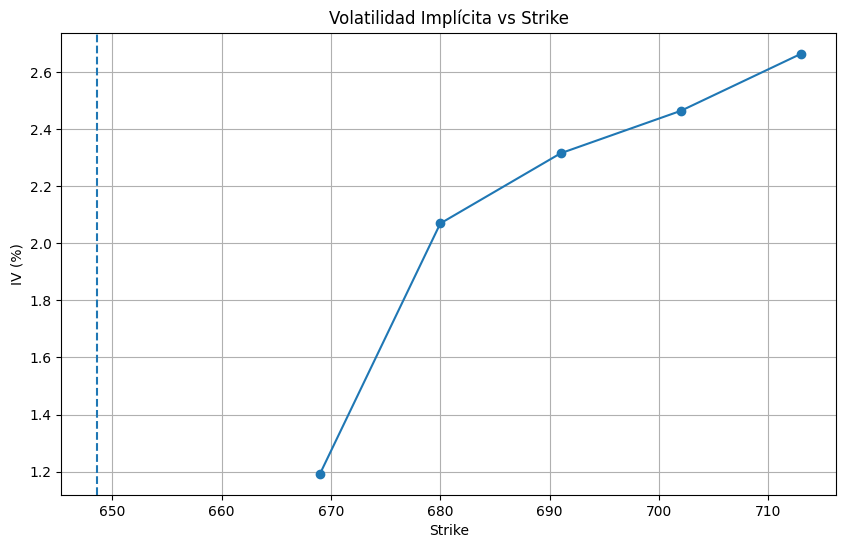

In [10]:
plt.figure(figsize=(10,6))

plt.plot(df_iv["Strike"], df_iv["IV (%)"], marker='o')

# Línea vertical en S0 (ATM)
plt.axvline(S0, linestyle='--')

plt.xlabel("Strike")
plt.ylabel("IV (%)")
plt.title("Volatilidad Implícita vs Strike")

plt.grid()
plt.show()

Responde dentro del notebook como celdas de texto (Markdown):

¿La curva de IV es decreciente, creciente o tiene forma de smile? ¿Qué implica eso?
La curva es creciente  lo que significa que  strikes bajos IV baja o strikes altos IV alta 
donde el mercado chance esta persiviendo  mayor incertidumbre en movimientos a la alza  y menor riesgo en caidas.



¿En qué strike es mínima la IV? ¿Coincide con S0?
en una curva creciente  la IV minima esta en los strokes mas bajos.
 no coinciden son s0 pero pueden estar cerca del ATM .si el minimo NO esta en s0 es decir, que el mercado tienes sesgos direccional( no cree en simetrias de movimientos) 



¿Qué estarían comprando los inversores que pagan una IV alta en strikes bajos?

que los inversores esta pagando un IV alata, es decir que estan comprando opciones  fuera del dinero apostadno a las subidas fuertes . entones el mercado esa dispuesto a  pagar  caro por upside y menos preocupaso por las caidas


¿Qué le diría esta curva a alguien que quiere usar Black–Scholes con una sola volatilidad constante?

pues este asume la volatilidad  constante , la IV cambia con el nivel del precio.
es decir que falla con una sola volatilidad 
